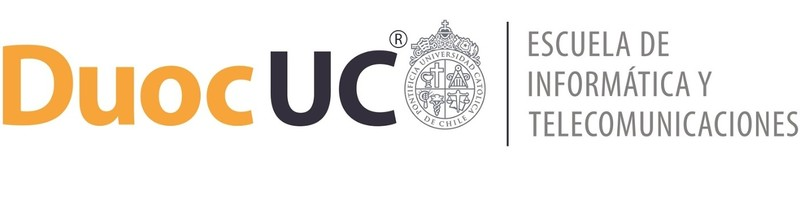

# Proyecto: Real State and House Price in Bangladesh


**Integrantes:** Nicolás Zamora

**Docente:** Carlos Muñoz

**Sección:** MINERIA_DE_DATOS_001

# Contexto del caso

Este conjunto de datos contiene listados de propiedades de varias ciudades de Bangladesh, incluidas específicamente Dhaka, Chattogram, Cumilla, Narayanganj City y Gazipur, con precios enumerados en taka bangladesí (৳). El conjunto de datos proporciona información valiosa sobre diversas características de las propiedades, incluida la cantidad de dormitorios, baños, número de piso, área de piso en pies cuadrados y sus respectivos precios. Los datos se han recopilado de un sitio web inmobiliario y ofrecen una visión integral del mercado inmobiliario en estas ciudades clave de Bangladesh.

Fuentes

https://www.kaggle.com/datasets/durjoychandrapaul/house-price-bangladesh



## Librerías y carga del Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Justificación**: Importamos las librerías necesarias según lo requiera el trabajo.

In [2]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

In [3]:
# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

## Bussines Understanding

**Mercado Inmobiliario en Bangladesh**

El objetivo de este proyecto es analizar y predecir el comportamiento de los precios de propiedades en las principales ciudades de Bangladesh, permitiendo que inversores, compradores y agentes tomen decisiones basadas en datos reales.

Descripción de variables:

* Title: El título o descripción del listado de propiedades.

* Bedrooms: El número de dormitorios de la propiedad.

* Bathrooms: El número de baños de la propiedad.

* Floor_no: el número de piso en el que se encuentra la propiedad.

* Occupancy_status: Indica si la propiedad está vacía u ocupada.

* Floor_area: La superficie total de la propiedad en m2.

* City: TLa ciudad donde se encuentra la propiedad. Incluye Dhaka, Chattogram, Cumilla, Narayanganj City, and Gazipur.

* Price_in_taka: Listado de precios de las propiedades en la moneda Bangladesa Taka (৳).

* Location: La ubicación o dirección específica dentro de la ciudad.

Objetivos Principales
Predicción de Precios: Entrenar un modelo que use Floor_area, Bedrooms y Location para calcular automáticamente cuánto debería costar una propiedad.

Análisis Comparativo: Identificar qué zonas son premium y cuáles son más accesibles según el Price_in_taka.

Pronóstico de Demanda: Detectar qué tipo de viviendas se necesitarán en el futuro para orientar a constructoras y políticas públicas.

**Impacto en el Negocio**

1. Para Inversores Evaluar si una propiedad está a "buen precio" comparándola con el mercado general.

2. Para Inmobiliarias: Establecer precios competitivos para nuevas construcciones basados en el valor real de la zona.

3. Para Compradores: Tener una guía clara para no pagar de más en ciudades como Dhaka o Chattogram.


In [4]:
df = pd.read_csv('house_price_bd.csv')

#Leemos el Dataset y le asociamos el DF para nombrarlo más abajo.

## Data Understanding


In [5]:
df.head(11) #visualizamos las primeras 5 filas

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3.0,4.0,3,vacant,1960.0,dhaka,"৳39,000,000","Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,"৳12,500,000","Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4,vacant,2125.0,dhaka,"৳20,000,000","Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3.0,3.0,4,vacant,2687.0,dhaka,"৳47,500,000","Road No 25, Banani"
5,Modern 1150 Sq Ft Flat For Sale In Badda,3.0,3.0,3,vacant,1150.0,dhaka,"৳8,800,000","Middle Badda, Badda"
6,2119 Sq Ft Apartment For Sale In Bashundhara R...,3.0,3.0,8,vacant,2119.0,dhaka,"৳19,000,000","Block B, Bashundhara R-A"
7,Live A Restful Life In This 2318 Square Feet F...,4.0,4.0,2,vacant,2318.0,dhaka,"৳23,000,000","Block D, Bashundhara R-A"
8,Worthy 1397 Sq Ft Nice Flat Is Ready For Sale ...,3.0,3.0,8,vacant,1397.0,dhaka,"৳8,000,000","Matuail, Demra"
9,Offering You 2400 Sq Ft Flat For Sale In Aftab...,3.0,3.0,1,vacant,2400.0,dhaka,"৳20,000,000","Block H, Aftab Nagar"


In [6]:
df.tail(11)

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
3854,1240 Sq Ft Flat For Sale Is Ready To Offer You...,3.0,3.0,8,vacant,1240.0,gazipur,"৳4,960,000","Joydebpur, Gazipur Sadar Upazila"
3855,Buy This 1240 Sq Ft Pleasant Flat In Gazipur S...,3.0,3.0,9,vacant,1240.0,gazipur,"৳4,960,000","Joydebpur, Gazipur Sadar Upazila"
3856,Buy This 920 Sq Ft Flat Which Is Ready To Grow...,3.0,2.0,9,vacant,920.0,gazipur,"৳3,220,000","Chandana, Gazipur Sadar Upazila"
3857,920 Sq Ft Cozy Flat With Impressive Features I...,3.0,2.0,9,vacant,920.0,gazipur,"৳3,220,000","Chandana, Gazipur Sadar Upazila"
3858,Buy This 1185 Square Feet Residential Apartmen...,3.0,3.0,7,vacant,1185.0,gazipur,"৳4,740,000","Shimultoly, Gazipur Sadar Upazila"
3859,Visit This Apartment For Sale In Bonomala Near...,NaN,NaN,NaN,NaN,NaN,gazipur,"৳3,357,750","Tongi, Gazipur Sadar Upazila"
3860,"Buy This 1350 Sq Ft Amazing Flat In Gazipur, J...",3.0,3.0,8,vacant,1350.0,gazipur,"৳4,500,000","Joydebpur, Gazipur Sadar Upazila"
3861,Properly Designed This 1000 Square Feet Apartm...,2.0,2.0,7,vacant,1000.0,gazipur,"৳4,300,000","Chandana, Gazipur Sadar Upazila"
3862,1240 Sq Ft Flat For Sale Is Awaiting You In Ga...,3.0,3.0,9,vacant,1240.0,gazipur,"৳4,960,000","Joydebpur, Gazipur Sadar Upazila"
3863,An Apartment Of 1300 Sq Ft Is Up For Sale In J...,3.0,3.0,9,vacant,1300.0,gazipur,"৳5,200,000","Joydebpur, Gazipur Sadar Upazila"


In [7]:
print("Dimensiones del dataset:")
print(df.shape)

Dimensiones del dataset:
(3865, 9)


In [8]:
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
Title                object
Bedrooms            float64
Bathrooms           float64
Floor_no             object
Occupancy_status     object
Floor_area          float64
City                 object
Price_in_taka        object
Location             object
dtype: object


In [9]:
print("Contaremos los Nulos de manera exacta en cada columna.")
df.isnull().sum()

Contaremos los Nulos de manera exacta en cada columna.


,0
Title,0
Bedrooms,1001
Bathrooms,1001
Floor_no,684
Occupancy_status,99
Floor_area,99
City,0
Price_in_taka,0
Location,6


Justificación: Ya al revisar los tipos de datos y los nulos que tenemos por cantidad exacta, podemos saber cuales tenemos que trabajar.

## Data Preparation

Lo primero que tenemos que hacer para comenzar a trabajar la data, es modelarla para lo que requiere el trabajo, tenemos muchos datos que están nulos, iremos parte por parte convirtiendo siguiendo el orden de variables por nombre.


Número de baños y piezas que estén nulos , cambiarlos por la media dependiendo de la ciudad para poder trabajarlos.

El floor_no que sea nulo cambiarlo a 1 ya que no pueden a ver pisos que sean en negativo o en 0.

La Occupancy_Status será cambiada de nulo a ocupada.

EL floor_area que tenga nulos lo adecuaremos a la media según la ciudad.



In [10]:
#Habitaciones y Baños: Cambiar nulos por la media dependiendo de la ciudad
df['Bedrooms'] = df.groupby('City')['Bedrooms'].transform(lambda x: x.fillna(x.mean()))
df['Bathrooms'] = df.groupby('City')['Bathrooms'].transform(lambda x: x.fillna(x.mean()))

# Redondear los valores de 'Bedrooms' y 'Bathrooms' y convertirlos a enteros
df['Bedrooms'] = df['Bedrooms'].round().astype(int)
df['Bathrooms'] = df['Bathrooms'].round().astype(int)

df.isnull().sum()

,0
Title,0
Bedrooms,0
Bathrooms,0
Floor_no,684
Occupancy_status,99
Floor_area,99
City,0
Price_in_taka,0
Location,6


Justificación: Al tener información nula de los baños y habitaciones, cambiamos estos a la media por ciudad ya que al dejarlos en 0, cambiará mucho el resultado al preparar la maquina.


In [11]:
# 2. Floor_no: Cambiar nulos a 1
df['Floor_no'] = df['Floor_no'].fillna(1)
df.isnull().sum()

,0
Title,0
Bedrooms,0
Bathrooms,0
Floor_no,0
Occupancy_status,99
Floor_area,99
City,0
Price_in_taka,0
Location,6


Justificación: EL Floor_no, al ser el número de pisos lo dejaremos en 1 ya que no puede ser 0 por defecto.

In [12]:
# 3. Occupancy_Status: Cambiar nulo a 'occupied'
# Se utiliza 'occupied' para mantener la consistencia con las etiquetas existentes en el CSV
df['Occupancy_status'] = df['Occupancy_status'].fillna('occupied')

df.isnull().sum()

,0
Title,0
Bedrooms,0
Bathrooms,0
Floor_no,0
Occupancy_status,0
Floor_area,99
City,0
Price_in_taka,0
Location,6


Justificación: Cambiaremos el estado de la vivienda a ocupada ya que no tenemos más
información sobre esas propiedades y no influirá en la futura toma decisiones que se
adecuan al proyecto.

In [13]:
#Floor_area: Imputar la media por ciudad
df['Floor_area'] = df.groupby('City')['Floor_area'].transform(lambda x: x.fillna(x.mean()))
df.isnull().sum()

,0
Title,0
Bedrooms,0
Bathrooms,0
Floor_no,0
Occupancy_status,0
Floor_area,0
City,0
Price_in_taka,0
Location,6


Justificación: El area de las propiedades se ajustarán a la media que hay por ciudad para poder evaluarlas mejor.

In [14]:
df.columns #mostramos los nombres de las columnas

Index(['Title', 'Bedrooms', 'Bathrooms', 'Floor_no', 'Occupancy_status',
       'Floor_area', 'City', 'Price_in_taka', 'Location'],
      dtype='object')

### Mapeo de Datos

1. Title:  Categórica Nominal
2. Bedrooms: Numérica Discreta
3. Bathrooms: Númerica Discreta
4. Floor_no: Númerica Discreta
5. Occupancy_status: Categórica Nominal
6. Floor_area: Numérica Continua
7. City: Categórica Nominal
8. Price_in_taka: Numérica Continua
9. Location: Categórica Nominal

In [15]:
display(df[['Title','Bedrooms','Bathrooms','Floor_no','Occupancy_status','City','Price_in_taka','Location']].head(3865))

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3,4,3,vacant,dhaka,"৳39,000,000","Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3,3,1,vacant,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3,3,6,vacant,dhaka,"৳12,500,000","Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3,3,4,vacant,dhaka,"৳20,000,000","Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3,3,4,vacant,dhaka,"৳47,500,000","Road No 25, Banani"
5,Modern 1150 Sq Ft Flat For Sale In Badda,3,3,3,vacant,dhaka,"৳8,800,000","Middle Badda, Badda"
6,2119 Sq Ft Apartment For Sale In Bashundhara R...,3,3,8,vacant,dhaka,"৳19,000,000","Block B, Bashundhara R-A"
7,Live A Restful Life In This 2318 Square Feet F...,4,4,2,vacant,dhaka,"৳23,000,000","Block D, Bashundhara R-A"
8,Worthy 1397 Sq Ft Nice Flat Is Ready For Sale ...,3,3,8,vacant,dhaka,"৳8,000,000","Matuail, Demra"
9,Offering You 2400 Sq Ft Flat For Sale In Aftab...,3,3,1,vacant,dhaka,"৳20,000,000","Block H, Aftab Nagar"


Justificación: Acá mostré todos los datos para confirmar la correcta categorización del mapa de datos.

### Variables Categóricas

In [16]:
# Contará la frecuencia de cada ubicación única

cant_cat_col_location_df = df['Location'].value_counts()
print(cant_cat_col_location_df)

# Imprimimos la cantidad total de categorías únicas
print(f"Cantidad de ubicaciones únicas: {cant_cat_col_location_df.count()}")

Location
Rupganj, Narayanganj                                               411
Dewan Bazar, Bakalia                                                98
Dhaka Trunk Road, 9 No. North Pahartali Ward                        92
Joydebpur, Gazipur Sadar Upazila                                    66
Tongi, Gazipur Sadar Upazila                                        57
24 No. North Agrabad Ward, Double Mooring                           51
Section 10, Mirpur                                                  49
12 No. Sarai Para Ward, Double Mooring                              45
Mohara, 4 No Chandgaon Ward                                         45
Section 12, Mirpur                                                  41
West Khulshi R/A, 9 No. North Pahartali Ward                        41
18 No. East Bakalia Ward, Bakalia                                   40
West Shewrapara, Mirpur                                             40
Pirerbag, Mirpur                                                    

Justificación: Podemos observar instantáneamente cuáles ciudades tienen la mayor cantidad de propiedades listadas y la frecuencia exacta de cada una, lo que proporciona una visión cualitativa y cuantitativa crucial sobre la concentración del mercado inmobiliario y los datos geográficos disponibles.

In [17]:
# Análisis para la columna 'City' (análogo a 'Región')
cant_cat_col_city_df = df['City'].value_counts() # Contará la frecuencia de cada ciudad única
print(cant_cat_col_city_df)

# Imprimimos la cantidad total de ciudades únicas
print(f"Cantidad de ciudades únicas: {cant_cat_col_city_df.count()}")

City
dhaka               1650
chattogram          1470
narayanganj-city     420
gazipur              180
cumilla              145
Name: count, dtype: int64
Cantidad de ciudades únicas: 5


Justificación: Se indica el número exacto de direcciones distintas en la columna City, lo cual es esencial para evaluar la granularidad de los datos, planificar estrategias y comprender el alcance geográfico general del dataset de una manera numérica y fácil de interpretar.

### Variables Númericas

In [18]:
df.describe()

,Bedrooms,Bathrooms,Floor_area
count,3865.000000,3865.000000,3865.000000
mean,3.098577,2.887193,1938.411907
std,1.907911,0.896684,5949.872042
min,1.000000,1.000000,84.000000
25%,3.000000,2.000000,1110.000000
50%,3.000000,3.000000,1400.000000
75%,3.000000,3.000000,1841.000000
max,50.000000,10.000000,195840.000000


Justificación: Acá, teníamos más variables númericas como el Floor_no y también Price_in_taka, por lo que las limpiaremos para poder trabajarlas como dato númerico.

In [19]:
# Limpiar 'Price_in_taka': Quitar '৳' y ',' y convertir a numérico
df['Price_in_taka'] = df['Price_in_taka'].astype(str).str.replace('৳', '', regex=False).str.replace(',', '', regex=False)
df['Price_in_taka'] = pd.to_numeric(df['Price_in_taka'], errors='coerce')

# Verificar el tipo de dato y los primeros valores
print(f"Tipo de dato de 'Price_in_taka' después de la limpieza: {df['Price_in_taka'].dtype}")
print("Primeros 5 valores de 'Price_in_taka':\n", df['Price_in_taka'].head())



Tipo de dato de 'Price_in_taka' después de la limpieza: int64
Primeros 5 valores de 'Price_in_taka':
 0    39000000
1    16900000
2    12500000
3    20000000
4    47500000
Name: Price_in_taka, dtype: int64


Justificación: vamos a limpiar la columna Floor_no. Esta columna contiene una mezcla de números, cadenas de texto como '8th', 'G+7', '1st', '4th to 8th Backside', y otros valores no numéricos. El objetivo es extraer el número de piso de estas cadenas, manejando rangos y otros formatos, y luego convertir la columna a un tipo numérico, rellenando los valores no válidos (NaN) con la mediana.

In [20]:
def clean_floor_no(floor_str):
    if pd.isna(floor_str):
        return np.nan

    floor_str = str(floor_str).lower().strip()

    # Handle specific complex cases first
    if 'g+7' in floor_str:
        return 7.0 # Assuming G+7 means 7 floors above ground
    if '0+7' in floor_str:
        return 7.0
    if '1f' in floor_str:
        return 1.0
    if 'merin city' in floor_str or 'a1,a2,a3,a4,a5,a6,a7' in floor_str:
        return np.nan # Cannot extract a single floor number

    # Handle ranges like '4th to 8th'
    if 'to' in floor_str:
        parts = floor_str.replace('th', '').replace('st', '').replace('nd', '').replace('rd', '').split('to')
        try:
            start = float(parts[0].strip())
            end = float(parts[1].strip())
            return (start + end) / 2
        except ValueError:
            pass

    # Extract numbers from strings like '8th', '1st'
    import re
    match = re.search(r'\d+', floor_str)
    if match:
        try:
            return float(match.group())
        except ValueError:
            pass

    return np.nan

# Aplicar la función de limpieza
df['Floor_no'] = df['Floor_no'].apply(clean_floor_no)

# Convertir a numérico, coercing errors a NaN
df['Floor_no'] = pd.to_numeric(df['Floor_no'], errors='coerce')

# Rellenar los valores NaN restantes con la mediana de la columna
median_floor_no = df['Floor_no'].median()
df['Floor_no'] = df['Floor_no'].fillna(median_floor_no)

# Convertir a entero
df['Floor_no'] = df['Floor_no'].astype(int)


# Verificar los valores únicos y el tipo de dato
print(f"Tipo de dato de 'Floor_no' después de la limpieza: {df['Floor_no'].dtype}")
print("Valores únicos de 'Floor_no' después de la limpieza:\n", df['Floor_no'].unique())


Tipo de dato de 'Floor_no' después de la limpieza: int64
Valores únicos de 'Floor_no' después de la limpieza:
 [ 3  1  6  4  8  2  5  7  9 10 14 13 12 11 18 17]


Justificación: Con las columnas Price_in_taka y Floor_no ya limpias y convertidas a tipos numéricos, podemos usar df.describe() para obtener un resumen estadístico completo que incluya estas variables.

In [34]:
df.describe()

,Bedrooms,Bathrooms,Floor_no,Floor_area,Price_in_taka
count,3865.000000,3865.000000,3865.000000,3865.000000,3.865000e+03
mean,3.098577,2.887193,3.835446,1938.411907,1.256311e+07
std,1.907911,0.896684,2.758825,5949.872042,2.911211e+07
min,1.000000,1.000000,1.000000,84.000000,6.600000e+01
25%,3.000000,2.000000,1.000000,1110.000000,4.900000e+06
50%,3.000000,3.000000,3.000000,1400.000000,7.000000e+06
75%,3.000000,3.000000,6.000000,1841.000000,1.100000e+07
max,50.000000,10.000000,18.000000,195840.000000,5.320000e+08


## Modeling


###Encode

In [25]:
import category_encoders as ce
from sklearn.preprocessing import OneHotEncoder

# Preparar las variables de baja cardinalidad (City y Occupancy_status) con OneHotEncoder
# sparse_output=False (o sparse=False dependiendo de la versión de sklearn) devuelve un array normal
ohe = OneHotEncoder(sparse_output=False, drop='first') # drop='first' es buena práctica para evitar multicolinealidad
baja_cardinalidad_encoded = ohe.fit_transform(df[['City', 'Occupancy_status']])

# Convertimos el resultado en un DataFrame
baja_card_df = pd.DataFrame(
    baja_cardinalidad_encoded,
    columns=ohe.get_feature_names_out(['City', 'Occupancy_status']),
    index=df.index
)

# Preparar la variable de alta cardinalidad (Location) con BinaryEncoder
# Como tienes 505 ubicaciones, esto creará aproximadamente 9 columnas en lugar de 505
be = ce.BinaryEncoder(cols=['Location'])
location_binary = be.fit_transform(df['Location'])

# Concatenar todo y eliminar las columnas originales de texto
# Se une el dataframe original (sin City, Occupancy_status y Location) con las nuevas columnas
df_final = pd.concat([df.drop(columns=['City', 'Occupancy_status', 'Location']), baja_card_df, location_binary], axis=1)

# Revisar los cambios
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")
display(df_final.head(15))

Total de columnas tras el mapeo: 20


,Title,Bedrooms,Bathrooms,Floor_no,Floor_area,Price_in_taka,City_cumilla,City_dhaka,City_gazipur,City_narayanganj-city,Occupancy_status_vacant,Location_0,Location_1,Location_2,Location_3,Location_4,Location_5,Location_6,Location_7,Location_8
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3,4,3,1960.0,39000000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,0,0,1
1,Valuable 1705 Square Feet Apartment Is Ready T...,3,3,1,1705.0,16900000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,0,1,0
2,1370 square feet apartment is ready to sale in...,3,3,6,1370.0,12500000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,0,1,1
3,2125 Square Feet Apartment For Sale In Bashund...,3,3,4,2125.0,20000000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,1,0,0
4,Buy This 2687 Square Feet Flat In The Nice Are...,3,3,4,2687.0,47500000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,1,0,1
5,Modern 1150 Sq Ft Flat For Sale In Badda,3,3,3,1150.0,8800000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,1,1,0
6,2119 Sq Ft Apartment For Sale In Bashundhara R...,3,3,8,2119.0,19000000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,0,1,1,1
7,Live A Restful Life In This 2318 Square Feet F...,4,4,2,2318.0,23000000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,1,0,0,0
8,Worthy 1397 Sq Ft Nice Flat Is Ready For Sale ...,3,3,8,1397.0,8000000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,1,0,0,1
9,Offering You 2400 Sq Ft Flat For Sale In Aftab...,3,3,1,2400.0,20000000,0.0,1.0,0.0,0.0,1.0,0,0,0,0,0,1,0,1,0


Justificación: En mi análisis apliqué dos estrategias de codificación distintas para optimizar el rendimiento del modelo según la cantidad de categorías. Para variables con pocas opciones, como la ciudad o el estado de ocupación, utilicé One-Hot Encoding, ya que crea un número pequeño y manejable de columnas binarias que el sistema procesa con facilidad. En cambio, para la variable de la ubicación, que contaba con 505 lugares diferentes, aplicar ese mismo método habría generado 505 columnas vacías casi en su totalidad, volviendo al modelo excesivamente lento y propenso a errores. Para evitar este colapso, apliqué Binary Encoding a la ubicación, una técnica matemática que traduce las categorías a lenguaje binario y nos permitió comprimir de forma inteligente los 505 lugares en tan solo 9 columnas, manteniendo toda la información geográfica intacta pero en un formato mucho más rápido, ligero y eficiente para entrenar el algoritmo.

###Distribución de datos

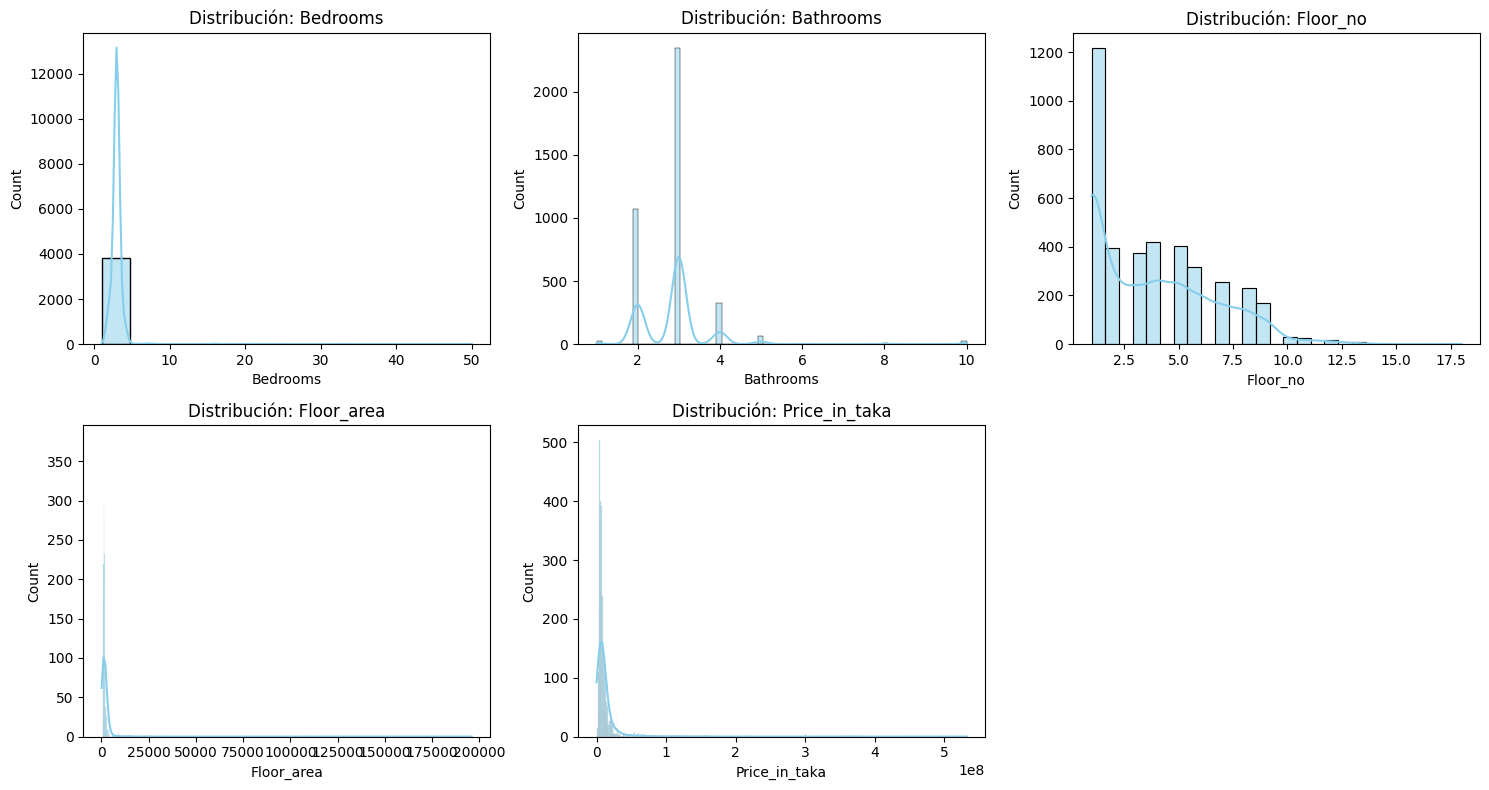

In [26]:
# Lista de columnas numéricas originales de tu dataset
cols_numericas = ['Bedrooms', 'Bathrooms', 'Floor_no', 'Floor_area', 'Price_in_taka']

# Configuración de gráficos
plt.figure(figsize=(15, 8))

# Como tenemos 5 columnas, creamos una cuadrícula de 2 filas x 3 columnas
for i, col in enumerate(cols_numericas, 1):
    plt.subplot(2, 3, i)
    # Histograma con curva de densidad
    sns.histplot(df_final[col], kde=True, color='skyblue')
    plt.title(f'Distribución: {col}')

plt.tight_layout()
plt.show()

Justificación de los histogramas por nombre de columnas.


1. Distribución Bedrooms: El gráfico señala que la caja del centro agrupa a la gran mayoría de las casas comunes y corrientes (el estándar de la ciudad), mientras que las líneas que salen de ella marcan la frontera de lo que aún se considera típico. Los datos que se ven más allá de esas líneas son Outliners, por ejemplo una mansión de ultra lujo o como la mansion que tiene 10 baños.


2. Distribución Bathrooms: Este gráfico señala que se construye y se vende en esas ciudades son los departamentos de 3 habitaciones. Encontrar un estudio de 1 habitación es raro, y una casa con 6 habitaciones también.

3. Distribución Floor_no: El gráfico muestra la distribución del número de pisos (Floor_no) donde se observa una clara concentración en pisos bajos (principalmente entre 1 y 5), con un pico en los primeros niveles, y una disminución progresiva a medida que aumenta el piso. La distribución es asimétrica hacia la derecha, ya que existen pocos casos en pisos altos (hasta aproximadamente el piso 18), lo que indica que estos son poco frecuentes.


4. Distribución Floor_area: La gran mayoría de las propiedades son de tamaño medio y precio accesible. Esa "cola" larga hacia la derecha representa las propiedades de lujo. Al haber una diferencia tan grande entre el precio más bajo y el más alto, aquí es donde se justifica que hayamos usado el escalamiento (StandardScaler) que hicimos antes, para que esos precios gigantes no vuelvan loco al algoritmo.

5. Distribución Price_in_taka: El gráfico muestra la distribución del precio (Price_in_taka) y evidencia una fuerte asimetría hacia la derecha, donde la gran mayoría de las propiedades se concentra en rangos de precios bajos, mientras que existe una cola larga con valores extremadamente altos que representan muy pocos casos. Esto indica la presencia de outliers significativos, probablemente propiedades de lujo o casos atípicos, que pueden distorsionar el análisis estadístico y los modelos de machine learning si no se tratan adecuadamente.

###Outliers

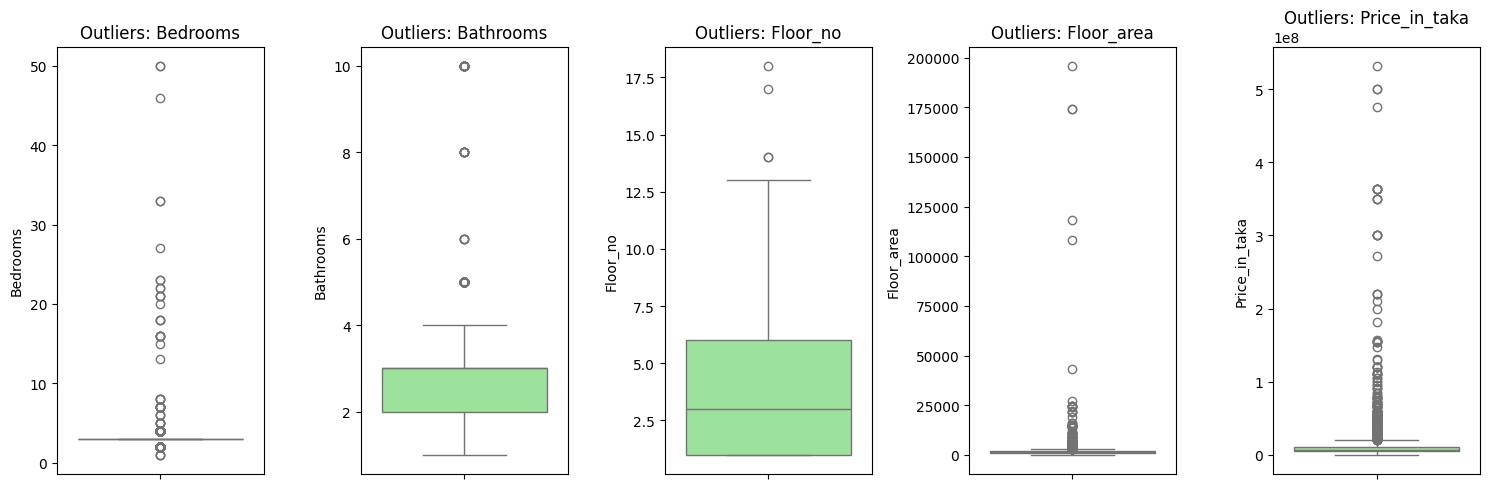

In [27]:
# Boxplot para detectar Outliers (Valores Atípicos) mejorado
plt.figure(figsize=(15, 5))

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(1, 5, i)
    # Se hace un boxplot individual para cada variable
    sns.boxplot(y=df_final[col], color='lightgreen')
    plt.title(f'Outliers: {col}')

plt.tight_layout()
plt.show()

**Outliners Bedrooms:** El "estándar" es tan rígido en 3 habitaciones que cualquier casa con 5 o más ya se considera una anomalía. Esto nos dice que tu dataset es muy uniforme en cuanto a tamaño familiar; las casas muy grandes son raras excepciones.


**Outliners Bathrooms:**  Confirma que en este mercado, tener 4 baños es "atípico". Si el modelo ve una casa con muchos baños, sabrá que es una propiedad especial (de lujo) y no una casa común.

**Outliners Floor_no:** Se confirma que la mayoría de las propiedades tienen unos 6 o 7 pisos. Los departamentos en pisos 15 o superiores son los de lujo.

**Outliners Floor_area:** Esto indica una desigualdad enorme. La mayoría de las casas son pequeñas, pero hay algunas propiedades tan gigantescas que hacen que el gráfico se estire al máximo.

**Outliners Price_in_taka:** El precio sigue al tamaño. Hay propiedades de ultra-lujo que cuestan 10 o 20 veces más que una casa normal. Para el modelo

###Estanderización de datos

In [29]:
from sklearn.preprocessing import StandardScaler

# Se establecen las columnas numéricas que queremos estandarizar
cols_a_escalar = ['Bedrooms', 'Bathrooms', 'Floor_no', 'Floor_area', 'Price_in_taka']

# Inicializamos el scaler
scaler = StandardScaler()

# Se desarrolla el scaler a df_final
# Usamos una copia para mantener la integridad de los datos originales
df_final_esc = df_final.copy()
df_final_esc[cols_a_escalar] = scaler.fit_transform(df_final[cols_a_escalar])

# 4. Verificación rápida
print("Primeras 5 filas con datos estandarizados:")
display(df_final_esc[cols_a_escalar].head())

Primeras 5 filas con datos estandarizados:


,Bedrooms,Bathrooms,Floor_no,Floor_area,Price_in_taka
0,-0.051674,1.241186,-0.302866,0.003629,0.908224
1,-0.051674,0.125821,-1.027906,-0.039235,0.148991
2,-0.051674,0.125821,0.784694,-0.095546,-0.002168
3,-0.051674,0.125821,0.059654,0.031364,0.255490
4,-0.051674,0.125821,0.059654,0.125832,1.200236


Justificación: Estos valores están estandarizados, es decir, ya no muestran números reales sino qué tan lejos está cada dato del promedio: los cercanos a 0 son normales, los positivos son más altos que el promedio y los negativos más bajos.

###Matriz de correlación

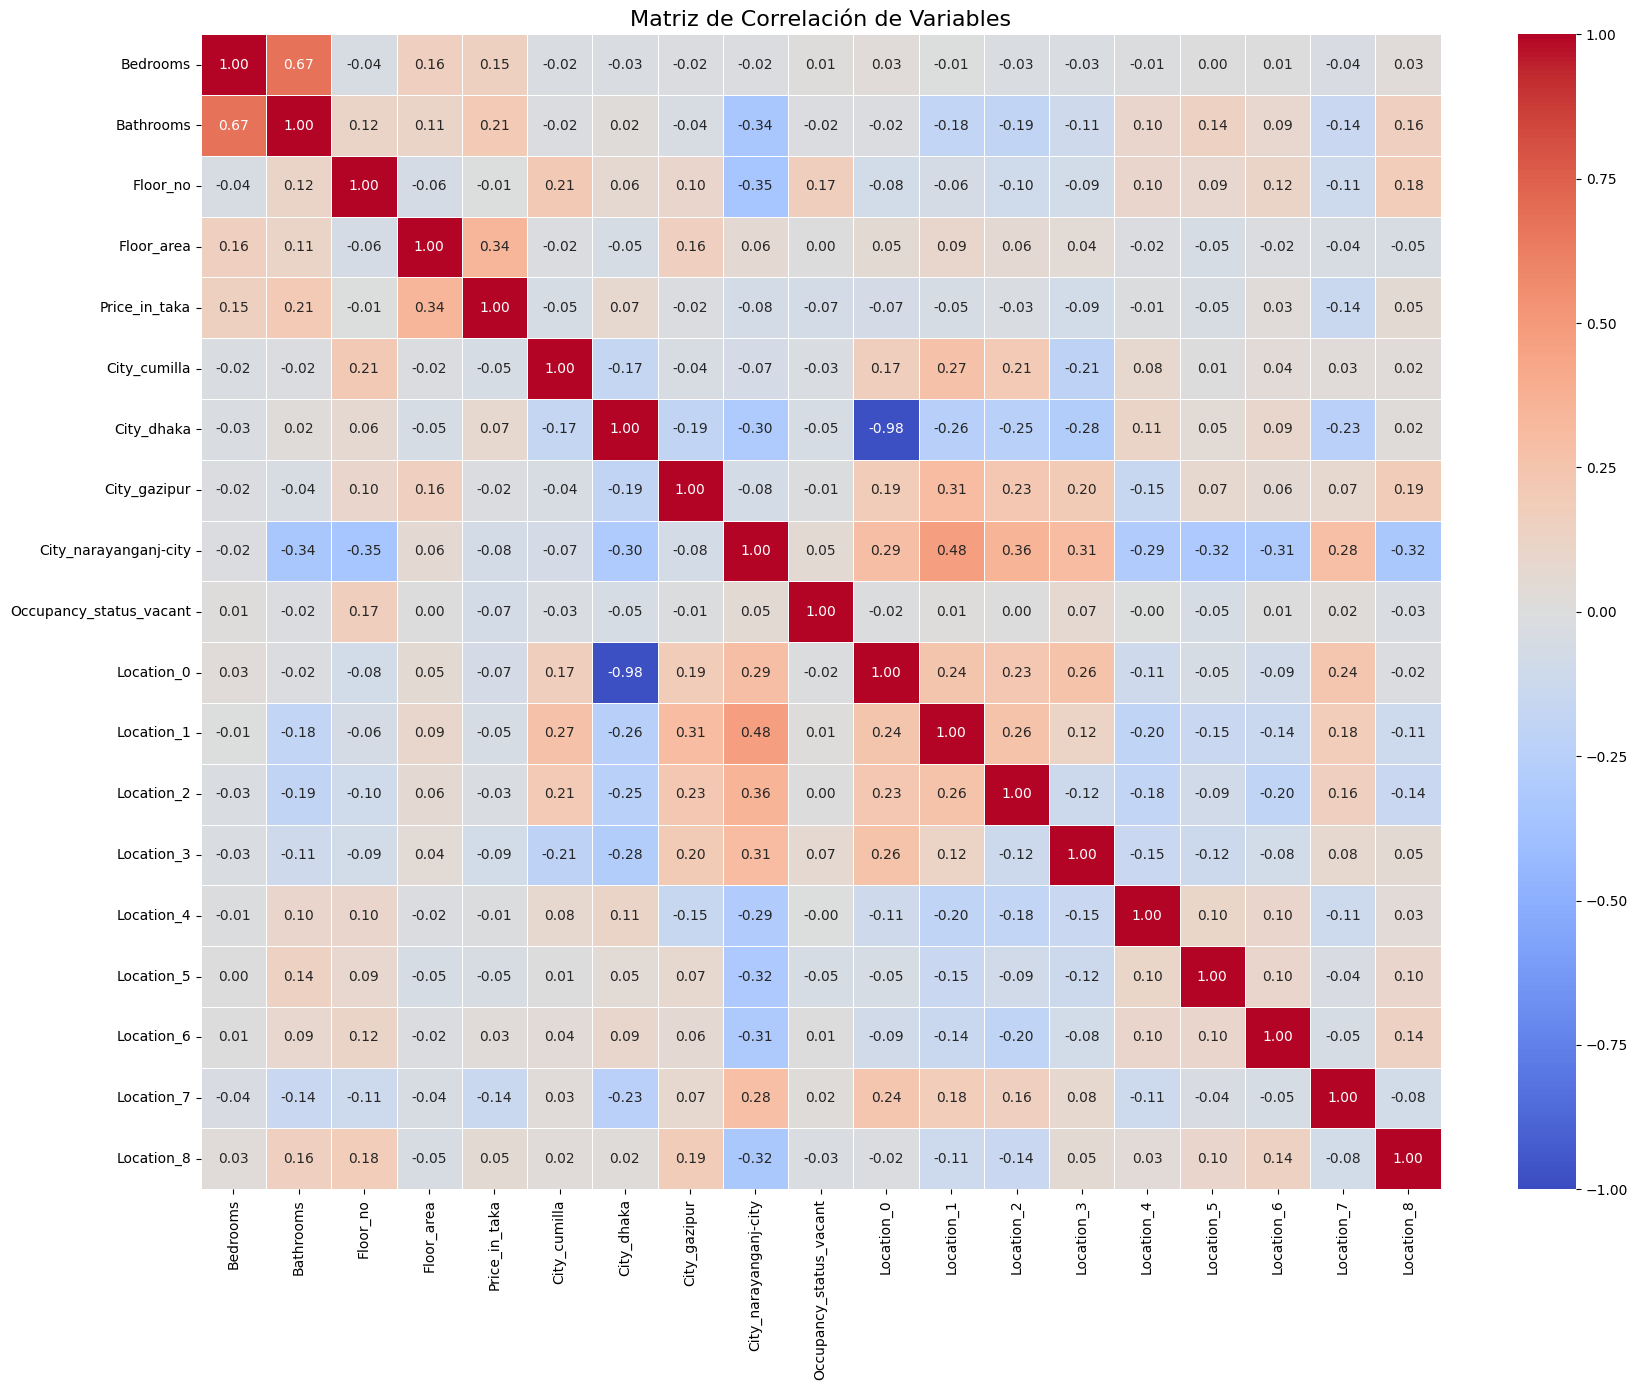

In [33]:
# Quitamos la columna 'Title' (texto) de nuestros datasets
df_final = df_final.drop(columns=['Title'], errors='ignore')
df_final_esc = df_final_esc.drop(columns=['Title'], errors='ignore')

# Calculamos la matriz de correlación.
corr_matrix = df_final_esc.corr()

# 3. Realizamos el Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title('Matriz de Correlación de Variables', fontsize=16)
plt.show()

Justificación: Primero eliminé la columna Title porque es texto y no aporta al cálculo de correlaciones, ya que este análisis solo funciona con datos numéricos. Luego generé la matriz de correlación para ver qué tan relacionadas están las variables entre sí, donde los valores van de -1 a 1 (indicando relaciones negativas, nulas o positivas). Finalmente, lo representé en un heatmap para visualizar mejor estas relaciones mediante colores. Gracias a esto, pude identificar patrones importantes, como que Bedrooms y Bathrooms tienen una relación fuerte o que el área del piso influye en el precio, lo que me ayuda a entender qué variables son más relevantes para el modelo de machine learning que comenzaré a trabajar en los siguientes encargos.